In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

In [11]:
df = pd.read_csv(r"C:\Users\HP\Documents\ML Project\loan-default-prediction-\data\application_train.csv")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nTarget distribution:")
print(df['TARGET'].value_counts())
print(f"\nDefault rate: {df['TARGET'].mean()*100:.2f}%")

Rows: 307,511
Columns: 122

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


## Business Observation 1: Class Imbalance

The dataset contains 307,511 loan applications. Only **8.07% defaulted**.

This means a naive model predicting "no default" for everyone would be 
91.93% accurate, yet completely useless to a lender.

**Implication:** We must:
- Use AUC-ROC and F1-score as evaluation metrics, NOT accuracy
- Apply SMOTE or class_weight='balanced' during modelling
- Report Precision-Recall curves, not just overall accuracy

In [15]:
print("====== DATA TYPES ======")
print(df.dtypes.value_counts())
print(df.head())

====== DATA TYPES ======
float64    65
int64      41
object     16
Name: count, dtype: int64
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0         202500.00   406597.50     24700.50   
1               N             0         270000.00  1293502.50     35698.50   
2               Y             0          67500.00   135000.00      6750.00   
3               Y             0         135000.00   312682.50     29686.50   
4               Y             0         121500.00   513000.00     21865.50   

   AMT_GOODS_PRICE NAME

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0')
.sort_values('missing_pct', ascending=False)

print(f"Total columns with missing values: {len(missing_df)}")
print(f"\nTop 20 columns by missing %:")
print(missing_df.head(20))

Total columns with missing values: 67

Top 20 columns by missing %:
                          missing_count  missing_pct
COMMONAREA_MEDI                  214865        69.87
COMMONAREA_AVG                   214865        69.87
COMMONAREA_MODE                  214865        69.87
NONLIVINGAPARTMENTS_MEDI         213514        69.43
NONLIVINGAPARTMENTS_MODE         213514        69.43
NONLIVINGAPARTMENTS_AVG          213514        69.43
FONDKAPREMONT_MODE               210295        68.39
LIVINGAPARTMENTS_MODE            210199        68.35
LIVINGAPARTMENTS_MEDI            210199        68.35
LIVINGAPARTMENTS_AVG             210199        68.35
FLOORSMIN_MODE                   208642        67.85
FLOORSMIN_MEDI                   208642        67.85
FLOORSMIN_AVG                    208642        67.85
YEARS_BUILD_MODE                 204488        66.50
YEARS_BUILD_MEDI                 204488        66.50
YEARS_BUILD_AVG                  204488        66.50
OWN_CAR_AGE                    

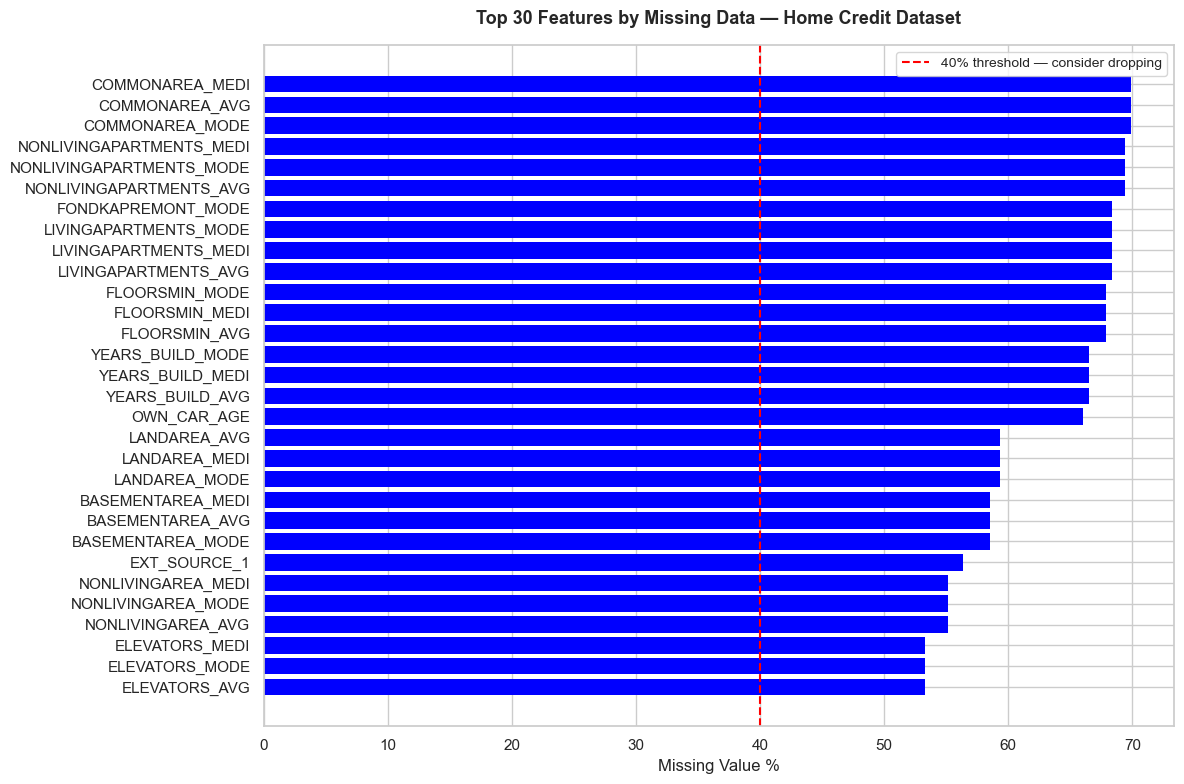

Chart saved to reports/


In [24]:
fig, ax = plt.subplots(figsize=(12, 8))

top_missing = missing_df.head(30)
bars = ax.barh(top_missing.index, top_missing['missing_pct'], 
               color='blue', edgecolor='none')

ax.axvline(x=40, color='red', linestyle='--', linewidth=1.5, 
           label='40% threshold — consider dropping')
ax.set_xlabel('Missing Value %', fontsize=12)
ax.set_title('Top 30 Features by Missing Data — Home Credit Dataset', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/")

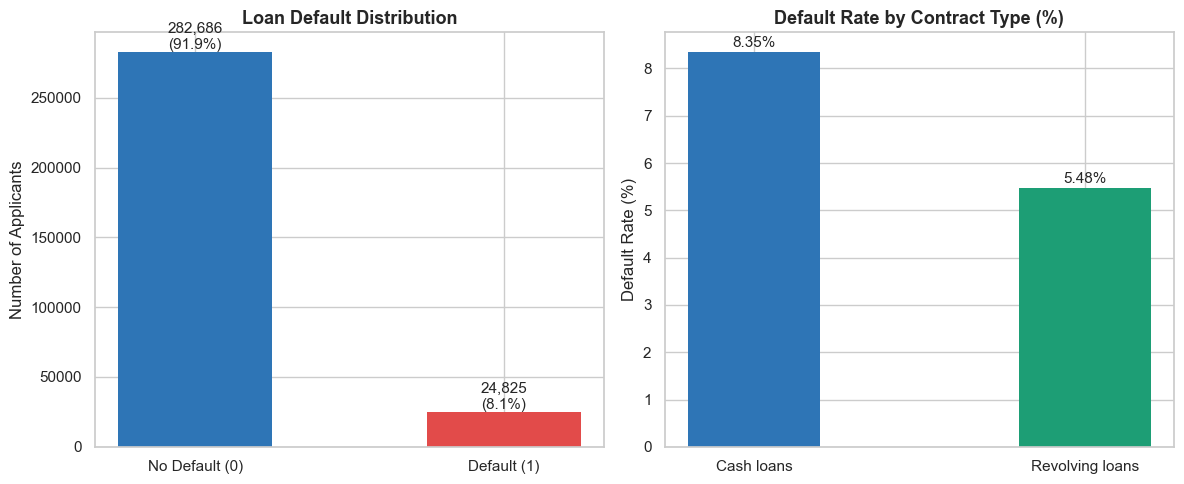

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['TARGET'].value_counts()
axes[0].bar(['No Default (0)', 'Default (1)'], counts.values, 
            color=['#2E75B6', '#E24B4A'], edgecolor='none', width=0.5)
axes[0].set_title('Loan Default Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Applicants')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2000, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                ha='center', fontsize=11)

# Default rate by contract type
contract_default = df.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean() * 100
axes[1].bar(contract_default.index, contract_default.values,
            color=['#2E75B6', '#1D9E75'], edgecolor='none', width=0.4)
axes[1].set_title('Default Rate by Contract Type (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
for i, v in enumerate(contract_default.values):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

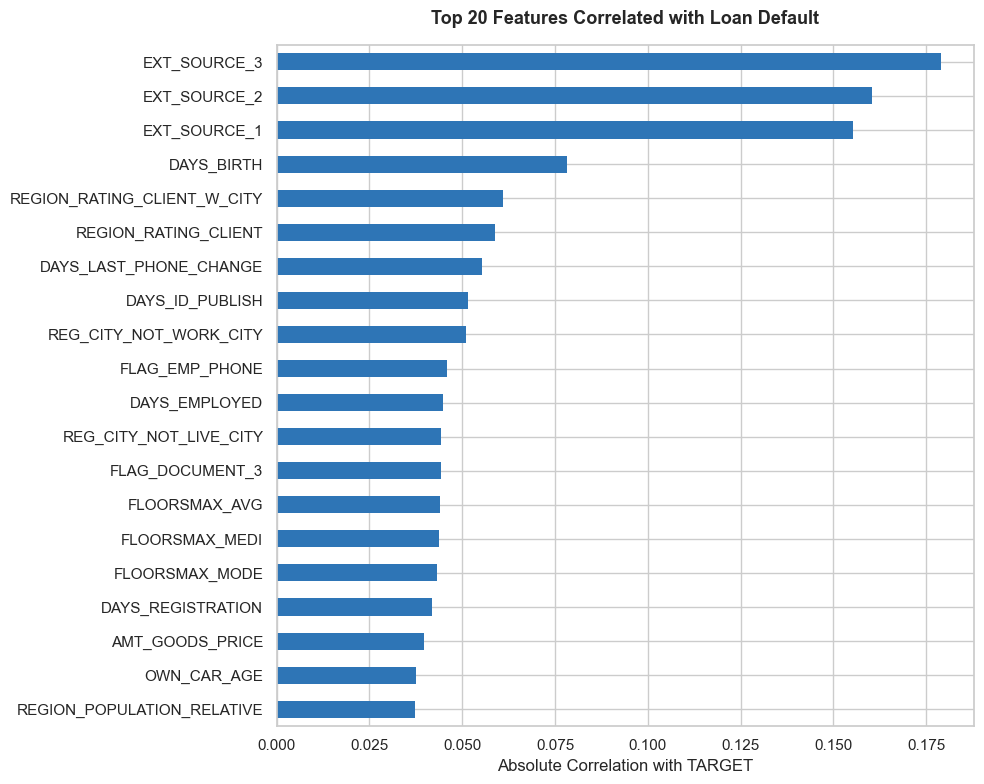


Top 10 correlated features:
EXT_SOURCE_3                  0.18
EXT_SOURCE_2                  0.16
EXT_SOURCE_1                  0.16
DAYS_BIRTH                    0.08
REGION_RATING_CLIENT_W_CITY   0.06
REGION_RATING_CLIENT          0.06
DAYS_LAST_PHONE_CHANGE        0.06
DAYS_ID_PUBLISH               0.05
REG_CITY_NOT_WORK_CITY        0.05
FLAG_EMP_PHONE                0.05
dtype: float64


In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'TARGET']

corr_with_target = df[numeric_cols].corrwith(df['TARGET']).abs()
top_corr = corr_with_target.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_corr.plot(kind='barh', ax=ax, color='#2E75B6', edgecolor='none')
ax.set_title('Top 20 Features Correlated with Loan Default', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Absolute Correlation with TARGET')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 correlated features:")
print(top_corr.head(10))

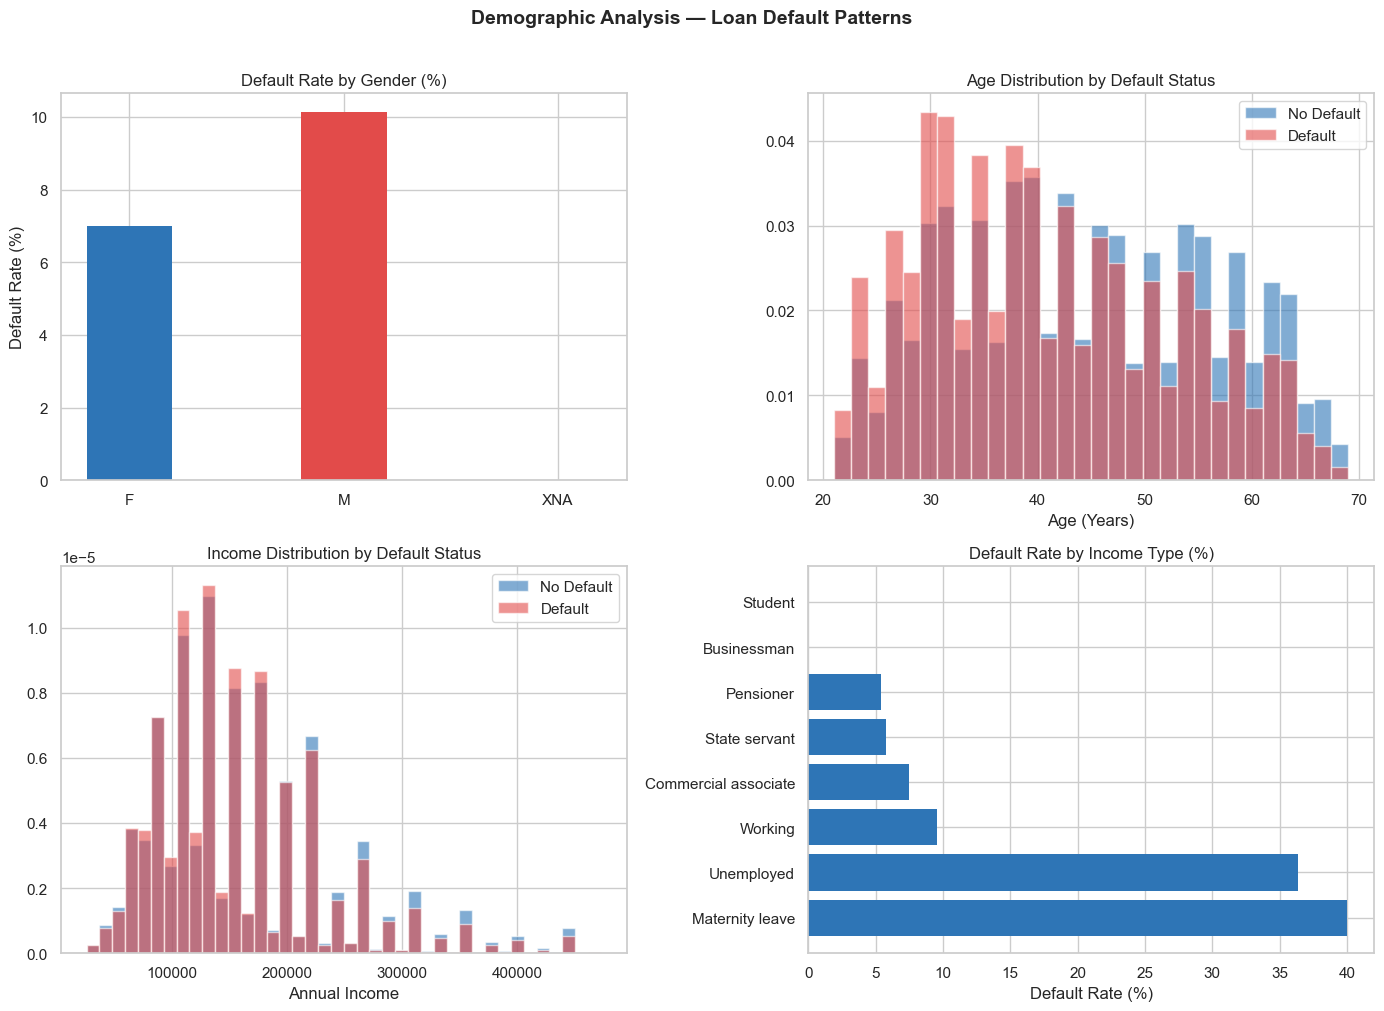

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Default rate by gender
gender_default = df.groupby('CODE_GENDER')['TARGET'].mean() * 100
axes[0,0].bar(gender_default.index, gender_default.values,
              color=['#2E75B6','#E24B4A','#888780'], edgecolor='none', width=0.4)
axes[0,0].set_title('Default Rate by Gender (%)')
axes[0,0].set_ylabel('Default Rate (%)')

# Age distribution (convert DAYS_BIRTH to years)
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).round(0)
default_age = df[df['TARGET']==1]['AGE_YEARS']
no_default_age = df[df['TARGET']==0]['AGE_YEARS']
axes[0,1].hist(no_default_age, bins=30, alpha=0.6, color='#2E75B6', label='No Default', density=True)
axes[0,1].hist(default_age, bins=30, alpha=0.6, color='#E24B4A', label='Default', density=True)
axes[0,1].set_title('Age Distribution by Default Status')
axes[0,1].set_xlabel('Age (Years)')
axes[0,1].legend()

# Income distribution (capped at 99th percentile to remove outliers)
income_cap = df['AMT_INCOME_TOTAL'].quantile(0.99)
df_capped = df[df['AMT_INCOME_TOTAL'] <= income_cap]
axes[1,0].hist(df_capped[df_capped['TARGET']==0]['AMT_INCOME_TOTAL'], 
               bins=40, alpha=0.6, color='#2E75B6', label='No Default', density=True)
axes[1,0].hist(df_capped[df_capped['TARGET']==1]['AMT_INCOME_TOTAL'], 
               bins=40, alpha=0.6, color='#E24B4A', label='Default', density=True)
axes[1,0].set_title('Income Distribution by Default Status')
axes[1,0].set_xlabel('Annual Income')
axes[1,0].legend()

# Default rate by income type
income_default = df.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False) * 100
axes[1,1].barh(income_default.index, income_default.values, color='#2E75B6', edgecolor='none')
axes[1,1].set_title('Default Rate by Income Type (%)')
axes[1,1].set_xlabel('Default Rate (%)')

plt.suptitle('Demographic Analysis — Loan Default Patterns', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/demographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

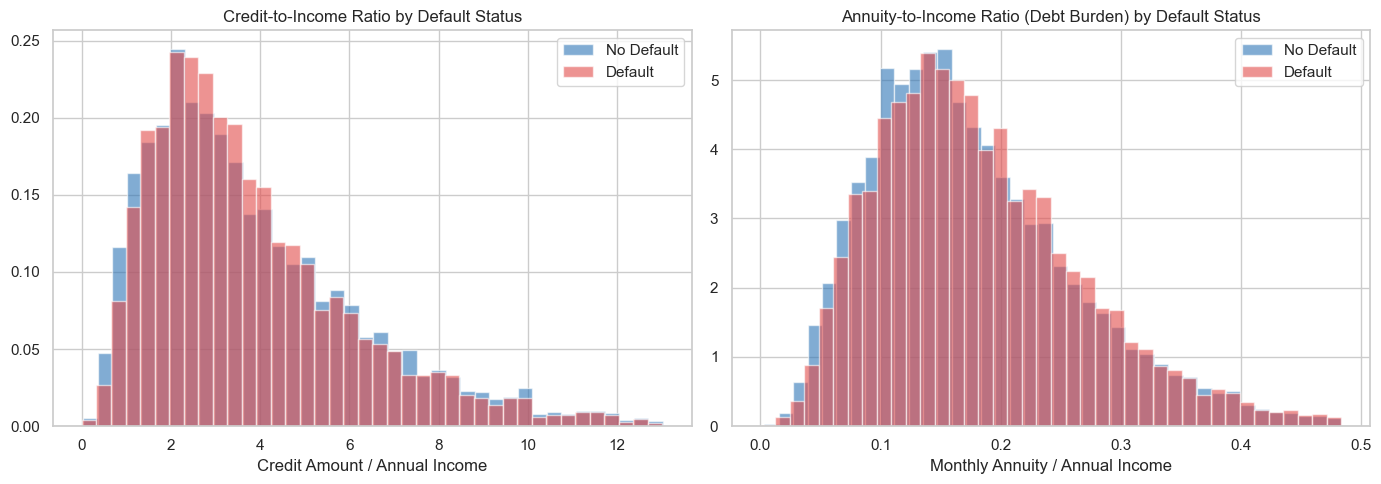

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Credit-to-income ratio
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
ratio_cap = df['CREDIT_INCOME_RATIO'].quantile(0.99)
df_ratio = df[df['CREDIT_INCOME_RATIO'] <= ratio_cap]

axes[0].hist(df_ratio[df_ratio['TARGET']==0]['CREDIT_INCOME_RATIO'],
             bins=40, alpha=0.6, color='#2E75B6', label='No Default', density=True)
axes[0].hist(df_ratio[df_ratio['TARGET']==1]['CREDIT_INCOME_RATIO'],
             bins=40, alpha=0.6, color='#E24B4A', label='Default', density=True)
axes[0].set_title('Credit-to-Income Ratio by Default Status')
axes[0].set_xlabel('Credit Amount / Annual Income')
axes[0].legend()

# Annuity-to-income ratio (debt burden)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
annuity_cap = df['ANNUITY_INCOME_RATIO'].quantile(0.99)
df_ann = df[df['ANNUITY_INCOME_RATIO'] <= annuity_cap]

axes[1].hist(df_ann[df_ann['TARGET']==0]['ANNUITY_INCOME_RATIO'],
             bins=40, alpha=0.6, color='#2E75B6', label='No Default', density=True)
axes[1].hist(df_ann[df_ann['TARGET']==1]['ANNUITY_INCOME_RATIO'],
             bins=40, alpha=0.6, color='#E24B4A', label='Default', density=True)
axes[1].set_title('Annuity-to-Income Ratio (Debt Burden) by Default Status')
axes[1].set_xlabel('Monthly Annuity / Annual Income')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/credit_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print("=" * 55)
print("EDA SUMMARY — HOME CREDIT DEFAULT RISK")
print("=" * 55)
print(f"\nDataset shape:       {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Default rate:        {df['TARGET'].mean()*100:.2f}%")
print(f"Missing value cols:  {missing_df.shape[0]} columns have missing data")
print(f"High missing (>40%): {len(missing_df[missing_df['missing_pct']>40])} columns")
print(f"\nTop 3 predictive features (by correlation):")
for i, (feat, val) in enumerate(top_corr.head(3).items(), 1):
    print(f"  {i}. {feat}: {val:.4f}")
print(f"\nEngineered features created:")
print(f"  - AGE_YEARS (from DAYS_BIRTH)")
print(f"  - CREDIT_INCOME_RATIO")
print(f"  - ANNUITY_INCOME_RATIO")
print(f"\nCharts saved to /reports/")
print(f"\nNext step: 02_feature_engineering.ipynb")
print("=" * 55)

EDA SUMMARY — HOME CREDIT DEFAULT RISK

Dataset shape:       307,511 rows × 125 columns
Default rate:        8.07%
Missing value cols:  67 columns have missing data
High missing (>40%): 49 columns

Top 3 predictive features (by correlation):
  1. EXT_SOURCE_3: 0.1789
  2. EXT_SOURCE_2: 0.1605
  3. EXT_SOURCE_1: 0.1553

Engineered features created:
  - AGE_YEARS (from DAYS_BIRTH)
  - CREDIT_INCOME_RATIO
  - ANNUITY_INCOME_RATIO

Charts saved to /reports/

Next step: 02_feature_engineering.ipynb
